# Bank Data Analysis

# Objective

In this case study, you will be working on Banking Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to give you hands-on experience in analyzing large-scale banking datasets using PySpark and AWS services. You will apply techniques learned in data analytics to clean, transform, and explore banking data, drawing meaningful insights to support financial decision-making. Apart from understanding how big data tools can optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing market capitalization trends, currency conversions, and global banking performance. Additionally, you will use AWS S3 to store the processed data once the ETL pipeline is complete, ensuring efficient data management and retrieval.


# Business Value

The banking industry operates in a highly competitive and globalized market where financial institutions must continuously monitor their market position, performance, and currency fluctuations. To stay competitive, banks must leverage data-driven insights to optimize their financial strategies, assess market trends, and make informed decisions. In this assignment, you will analyze banking data to uncover patterns in market capitalization, currency conversions, and global rankings. With Apache Spark's ability to handle large datasets efficiently, financial institutions can process vast amounts of data in real-time, helping them make faster and more informed decisions.


As an analyst at a financial institution, your task is to examine historical banking data to derive actionable insights that can drive strategic growth. Your analysis will help identify the top 10 largest banks by market capitalization, convert market cap values into multiple currencies (USD, GBP, EUR, INR), and store the processed data for easy retrieval. To enhance scalability and accessibility, you will utilize AWS S3 for data storage, ensuring seamless integration with cloud-based analytics tools. By leveraging big data analytics and cloud services, financial institutions can streamline operations, enhance decision-making, and maximize revenue opportunities.


# Dataset

The data for this project can be accessed from the following [wikipedia link](https://web.archive.org/web/20230908091635/https://en.wikipedia.org/wiki/List_of_largest_banks).

The dataset used in this analysis comprises global banking data extracted from a Wikipedia page (List of Largest Banks) archived as of September 2023.

It includes rankings of the world's largest banks based on market capitalization (in USD billions) and is structured into a single table with three columns. The data was scraped programmatically, cleaned, and transformed using PySpark to support cross-currency analysis. Exchange rate data (for USD, GBP, EUR, and INR) was sourced from a CSV file to enable currency conversions. The processed dataset is stored in CSV and SQLite formats for accessibility and efficient querying.

The dataset consists of a single table (Largest_banks) with the following three key attributes:
- **Rank:** Numerical position of the bank based on market capitalization.
- **Bank Name:** Name of the financial institution.
- **Market Cap (USD Billion):** Market valuation of the bank in USD billions.
This dataset enables analysis of global banking trends, cross-currency valuations, and the relative market dominance of financial institutions.

An additional data on market exchange rates is available to compare the marketcap dealing with different currencies.


<h2>Assignment Tasks</h2>

<ol>
    <li>
        <strong>Data Preparation</strong>
        <p>The dataset consists of a structured table containing global banking data. Before performing any analysis, it is crucial to prepare the data to ensure consistency and efficiency in processing.</p>
        Check for data consistency and ensure all columns are correctly formatted.<br>
        Structure and prepare the data for further processing and analysis.<br>
</br>
    <li>
        <strong>Data Cleaning</strong>
        <ul>
            2.1. <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.<br>
            2.2. <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.<br>
            2.3. <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.<br>
        </ul>
</br>
    <li>
        <strong>Exploratory Data Analysis:</strong></br>
            EDA Finding Patterns - Analyze the dataset and find patterns based on the following points:
                <ul>
                    3.1. Convert PySpark DataFrame to Pandas DataFrame for visualization.<br>
                    3.2. Analyze the distribution of market capitalization using a histogram.<br>
                    3.3. Identify the top 10 banks by market capitalization using a bar chart.<br>
                    3.4. Visualize the relationship between market capitalization and bank ranking using a scatter plot.<br>
                    3.5. Use a boxplot to examine the spread and outliers in market capitalization.<br>
                    3.6. Display the quartile distribution of market capitalization using a violin plot.<br>
                    3.7. Compute cumulative market share and visualize it with a line plot.<br>
                    3.8. Categorize banks into market capitalization ranges and analyze their distribution using a bar chart.<br>
                    3.9. Calculate and display market share distribution of top 10 banks using a pie chart.<br>
                </ul>
        </ul>
</br>
    <li>
        <strong>Banking Data ETL Querying</strong>
        <ul>
            4.1. Perform Advanced Market Capitalization Analysis with Growth Metrics.<br>
            4.2. Analyze Market Concentration and Categorize Banks Based on Market Share Tiers.<br>
            4.3. Examine Statistical Distribution of Market Capitalization Using Quartile Analysis.<br>
            4.4. Conduct Comparative Size Analysis to Classify Banks by Relative Market Size.<br>
            4.5. Evaluate Market Growth and Identify Gaps Between Consecutive Banks.<br>
            4.6. Assess Market Dominance by Measuring Cumulative Share and Dominance Score.<br>
            4.7. Analyze Segment-Wise Bank Performance Based on Market Capitalization Ranges.<br>
            4.8. Generate a Comprehensive Performance Dashboard for Bank Rankings and Metrics.<br>
        </ul>
    </br>
    <li>
        <strong>Conclusion</strong></br>
            Provide final insights and recommendations based on the analysis:</br>
            <ul>
            5.1 Recommendations to track and compare market capitalisation of the top global banks toevaluate competitiveness and dominance.</br>
            5.2 Suggestions to use cross-currency analysis (USD, GBP, EUR, INR) for consistent benchmarking
of financial institutions across regions.</br>
            5.3 Propose continuous monitoring of market share concentration to identify growth opportunities
for mid-tier banks.</br>
            5.4  Identify potential regions or banking segments for expansion by analysing gaps between tiers
of banks and regional trends.</br>
            </ul>
    </br>
    <li>
        <strong>Visualization Integration [Optional]</strong>
        <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
        </ul>
</ol>

Import Required Libraries

In [7]:
# # Install the required libraries
!pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [8]:
import sys
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install lxml


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: C:\Users\Niroj\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: C:\Users\Niroj\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [9]:
# Import required libraries
import logging
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
# Import PySpark libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [10]:
import os, sys
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [11]:
# Initialize Spark session
spark = (
    SparkSession.builder
    .appName("BankingDataAnalysis")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.ui.port", "4050")  # optional
    .getOrCreate()
)

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>


The data for this project can be accessed from the wikipedia link provided above. The page features data regarding global banking data.

Utilise the pandas method to read tables from the html document
and extract the requried data consists of a structured format.

Before performing any analysis, it is crucial to prepare the data to ensure consistency, and efficiency in processing.

In [13]:
import requests
from io import StringIO 

In [14]:
# Initialize Spark session

# URL of the Wikipedia page

# Use pandas to read all HTML tables from the page

# Load the correct table (Table 1)

# Convert pandas DataFrame to PySpark DataFrame

# Rename columns

# Show the first few rows of the PySpark DataFrame

# Print the schema of the DataFrame

# Configure logging


In [15]:
# URL of the Wikipedia page
url = "https://web.archive.org/web/20230908091635/https://en.wikipedia.org/wiki/List_of_largest_banks"

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)
response.raise_for_status()  # ensures no 423 or 429 error

# Use pandas to read all HTML tables from the page
tables= pd.read_html(StringIO(response.text))
print(f"{len(tables)} tables found")

# Load the correct table (Table 1)
df_pd = tables[0] # it loads the first table
df_pd.head(10)

3 tables found


,Rank,Bank name,Market cap (US$ billion)
0,1,JPMorgan Chase,432.92
1,2,Bank of America,231.52
2,3,Industrial and Commercial Bank of China,194.56
3,4,Agricultural Bank of China,160.68
4,5,HDFC Bank,157.91
5,6,Wells Fargo,155.87
6,7,HSBC Holdings PLC,148.90
7,8,Morgan Stanley,140.83
8,9,China Construction Bank,139.82
9,10,Bank of China,136.81


In [16]:
df_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rank                      10 non-null     int64  
 1   Bank name                 10 non-null     object 
 2   Market cap (US$ billion)  10 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 368.0+ bytes


In [17]:
df_pd.shape

(10, 3)

In [18]:
# Convert pandas DataFrame to PySpark DataFrame
df_spark = spark.createDataFrame(df_pd)

In [19]:
df_spark.printSchema()

root
 |-- Rank: long (nullable = true)
 |-- Bank name: string (nullable = true)
 |-- Market cap (US$ billion): double (nullable = true)



In [20]:
df_spark.show(5)

+----+--------------------+------------------------+
|Rank|           Bank name|Market cap (US$ billion)|
+----+--------------------+------------------------+
|   1|      JPMorgan Chase|                  432.92|
|   2|     Bank of America|                  231.52|
|   3|Industrial and Co...|                  194.56|
|   4|Agricultural Bank...|                  160.68|
|   5|           HDFC Bank|                  157.91|
+----+--------------------+------------------------+
only showing top 5 rows


In [21]:
df_spark.columns

['Rank', 'Bank name', 'Market cap (US$ billion)']

In [22]:
# Rename columns
df_spark = df_spark.withColumnRenamed("Rank", "Bank_Rank") \
                   .withColumnRenamed("Bank name", "Bank_Name") \
                   .withColumnRenamed("Market cap (US$ billion)", "Market_Capitalisation (USD Billion)")

In [23]:
# Show the first few rows of the PySpark DataFrame
df_spark.show(10)


+---------+--------------------+-----------------------------------+
|Bank_Rank|           Bank_Name|Market_Capitalisation (USD Billion)|
+---------+--------------------+-----------------------------------+
|        1|      JPMorgan Chase|                             432.92|
|        2|     Bank of America|                             231.52|
|        3|Industrial and Co...|                             194.56|
|        4|Agricultural Bank...|                             160.68|
|        5|           HDFC Bank|                             157.91|
|        6|         Wells Fargo|                             155.87|
|        7|   HSBC Holdings PLC|                              148.9|
|        8|      Morgan Stanley|                             140.83|
|        9|China Constructio...|                             139.82|
|       10|       Bank of China|                             136.81|
+---------+--------------------+-----------------------------------+



In [24]:
# Print the schema of the DataFrame

df_spark.printSchema()


root
 |-- Bank_Rank: long (nullable = true)
 |-- Bank_Name: string (nullable = true)
 |-- Market_Capitalisation (USD Billion): double (nullable = true)



In [25]:
# Configure logging
spark.sparkContext.setLogLevel("WARN")

print("Spark logging level has been set to WARN")

Spark logging level has been set to WARN


Load the data for exchange rates

In [27]:
# Load the exchange rate data
df_exchange_rate = spark.read.csv("exchange_rate(in).csv", header=True, inferSchema=True)
# Show the first few rows of the exchange rate data to verify
df_exchange_rate.show()

+--------+-----+
|Currency| Rate|
+--------+-----+
|     EUR| 0.93|
|     GBP|  0.8|
|     INR|82.95|
+--------+-----+



#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>

##**2.1 Handle Missing Values** <font color = red>[10 marks]</font> <br>


In [30]:
# Print the schema to check data types
df_spark.printSchema()

root
 |-- Bank_Rank: long (nullable = true)
 |-- Bank_Name: string (nullable = true)
 |-- Market_Capitalisation (USD Billion): double (nullable = true)



In [31]:
# Check for missing values
from pyspark.sql.functions import col, count, when

missing_values = [count(when(col(c).isNull(), c)).alias(c) for c in df_spark.columns]

df_spark.select(missing_values).show()


+---------+---------+-----------------------------------+
|Bank_Rank|Bank_Name|Market_Capitalisation (USD Billion)|
+---------+---------+-----------------------------------+
|        0|        0|                                  0|
+---------+---------+-----------------------------------+



In [32]:
# Drop rows with missing values
# no missing values in the data. we do not need to drop rows with missing value.

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


The Market cap is already in numeric so no conversion needed.

In [35]:
# Count the total number of rows
total_rows_count = df_spark.count()

# Check if there are duplicates
unique_rows_count = df_spark.distinct().count()
duplicate_rows_count = total_rows_count - unique_rows_count

# Display
print(f"Total number of rows in the dataset: {total_rows_count}")
print(f" Duplicate records found: {duplicate_rows_count}")

Total number of rows in the dataset: 10
 Duplicate records found: 0


##**2.2 Handle Outliers** <font color = red>[5 marks]</font> <br>


In [37]:
# Write code for outlier analysis
from pyspark.sql.functions import col, percentile_approx

Quantiles=  df_spark.select(
    percentile_approx(col("Market_Capitalisation (USD Billion)"), 0.25).alias("Q1"),
    percentile_approx(col("Market_Capitalisation (USD Billion)"), 0.75).alias("Q3")).collect()[0]

# Calculate IQR and bounds
Q1 = Quantiles["Q1"]
Q3 = Quantiles["Q3"]
IQR = Q3 - Q1

lower_limit= Q1-1.5*IQR
upper_limit= Q3+1.5*IQR

# Find Outliers
Outliers= df_spark.filter((col("Market_Capitalisation (USD Billion)") < lower_limit) | (col("Market_Capitalisation (USD Billion)") > upper_limit))

# Display Outliers
print("Detected Outliers:")
Outliers.show()

Detected Outliers:
+---------+--------------+-----------------------------------+
|Bank_Rank|     Bank_Name|Market_Capitalisation (USD Billion)|
+---------+--------------+-----------------------------------+
|        1|JPMorgan Chase|                             432.92|
+---------+--------------+-----------------------------------+



Saving the Cleaned Dataset into a CSV File into the S3 Bucket


#**3. Exploratory Data Analysis** <font color = red>[40 marks]</font> <br>


##**3.1. Conversion from PySpark to Pandas DataFrame** <font color = red>[5 marks]</font> <br>

Convert PySpark DataFrame to Pandas DataFrame for visualization

In [41]:
# Convert PySpark DataFrame to Pandas DataFrame
df_pandas = df_spark.toPandas()
df_pandas.head()


,Bank_Rank,Bank_Name,Market_Capitalisation (USD Billion)
0,1,JPMorgan Chase,432.92
1,2,Bank of America,231.52
2,3,Industrial and Commercial Bank of China,194.56
3,4,Agricultural Bank of China,160.68
4,5,HDFC Bank,157.91


##**3.2. Market Capitalization** <font color = red>[5 marks]</font> <br>

Analyze the distribution of market capitalization using a histogram

In [43]:
# Distribution of Market Cap (US$ Billion)

Market_Cap_Distribution = df_pandas["Market_Capitalisation (USD Billion)"]
print(" Market Cap distribution")
print(Market_Cap_Distribution.describe())


 Market Cap distribution
count     10.000000
mean     189.982000
std       90.223932
min      136.810000
25%      142.847500
50%      156.890000
75%      186.090000
max      432.920000
Name: Market_Capitalisation (USD Billion), dtype: float64


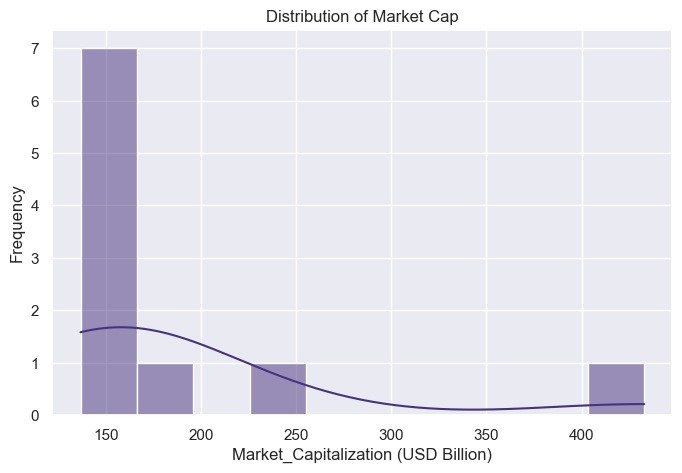

In [44]:
# Set the style for seaborn
sns.set(style="darkgrid")
sns.set_palette("viridis")

# Plot the distribution of market cap
plt.figure(figsize=(8,5))
sns.histplot(Market_Cap_Distribution, kde=True, bins=10)

plt.title("Distribution of Market Cap")
plt.xlabel("Market_Capitalization (USD Billion)")
plt.ylabel("Frequency")

plt.show()

##**3.3. Top 10 Banks** <font color = red>[5 Marks]</font> <br>

Identify the top 10 banks by market capitalization using a bar chart

In [46]:
# Top 10 Banks by Market Cap
## Sort the DataFrame by market cap in descending order 

Top_10_Banks_by_Market_Cap = df_pandas.sort_values(by="Market_Capitalisation (USD Billion)", ascending=False)
Top_10_Banks_by_Market_Cap.head(10)

,Bank_Rank,Bank_Name,Market_Capitalisation (USD Billion)
0,1,JPMorgan Chase,432.92
1,2,Bank of America,231.52
2,3,Industrial and Commercial Bank of China,194.56
3,4,Agricultural Bank of China,160.68
4,5,HDFC Bank,157.91
5,6,Wells Fargo,155.87
6,7,HSBC Holdings PLC,148.90
7,8,Morgan Stanley,140.83
8,9,China Construction Bank,139.82
9,10,Bank of China,136.81


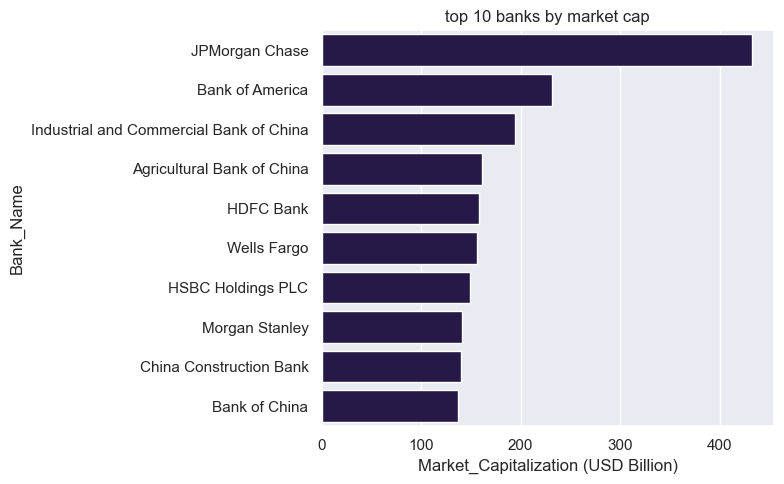

In [47]:
# Plot the top 10 banks by market cap
sns.set(style="darkgrid")
sns.set_palette("magma")

plt.figure(figsize=(8,5))
sns.barplot(x="Market_Capitalisation (USD Billion)",  y= "Bank_Name", data=Top_10_Banks_by_Market_Cap)

plt.title("top 10 banks by market cap")
plt.xlabel("Market_Capitalization (USD Billion)")
plt.ylabel("Bank_Name")

plt.tight_layout()
plt.show()

##**3.4. Market Cap vs Bank Ranking** <font color = red>[5 Marks]</font> <br>

Visualize the relationship between market capitalization and bank ranking using a scatter plot

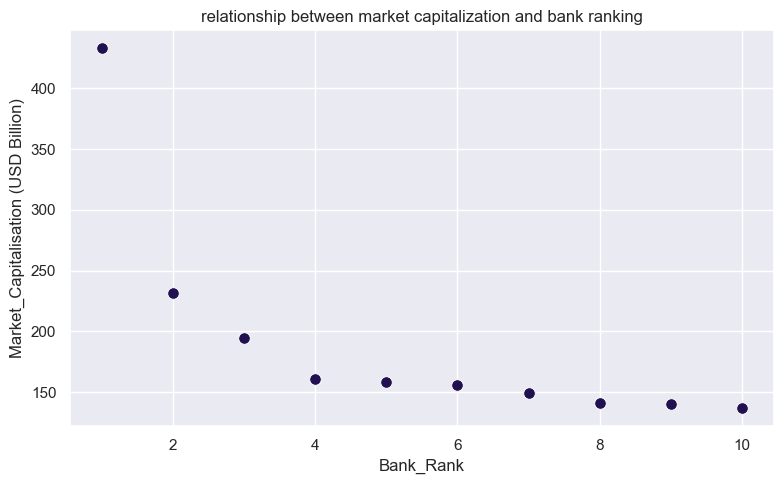

In [49]:
# Market Cap vs Rank
# Plot market cap vs rank
sns.set(style="darkgrid")
sns.set_palette("magma")

plt.figure(figsize=(8,5))
sns.scatterplot(x="Bank_Rank",y="Market_Capitalisation (USD Billion)", data=Top_10_Banks_by_Market_Cap, s=70, marker= "o")

plt.title("relationship between market capitalization and bank ranking")
plt.xlabel("Bank_Rank")
plt.ylabel("Market_Capitalisation (USD Billion)")

plt.tight_layout()
plt.show()

##**3.5. Market Cap Analysis** <font color = red>[5 Marks]</font> <br>

Use a boxplot to examine the spread and outliers in market capitalization.

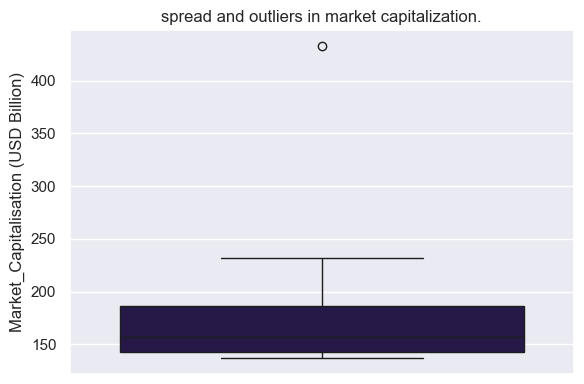

In [51]:
# Boxplot of Market Cap
#To show the spread and outliers in the market capitalization data.
# Plot a boxplot of market cap

plt.figure(figsize=(6,4))
sns.boxplot( y=df_pandas["Market_Capitalisation (USD Billion)"])

plt.title("spread and outliers in market capitalization.")
plt.tight_layout()
plt.show()

##**3.6. Market Cap Quartile Distribution** <font color = red>[5 Marks]</font> <br>

Display the quartile distribution of market capitalization using a violin plot.

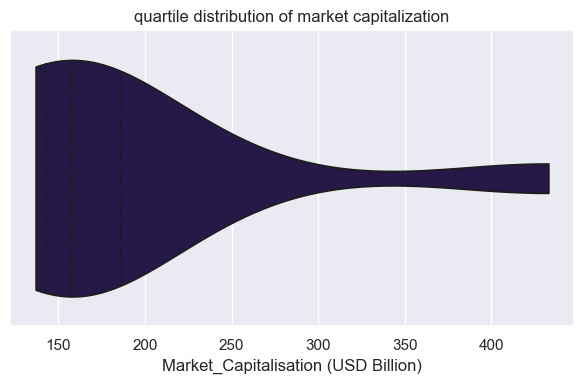

In [53]:
# Market Cap Distribution by Quartile
plt.figure(figsize=(6,4))
sns.violinplot(x=df_pandas["Market_Capitalisation (USD Billion)"], inner="quart", cut=0)

plt.title("quartile distribution of market capitalization")
plt.xlabel("Market_Capitalisation (USD Billion)")

plt.tight_layout()
plt.show()

##**3.7. Cumulative Market Share Analysis** <font color = red>[5 Marks]</font> <br>

Compute cumulative market share and visualize it with a line plot.

In [55]:
# Cumulative Market Share

df_pandas["Cumulative_Market_Share"] = (df_pandas["Market_Capitalisation (USD Billion)"].cumsum() / df_pandas["Market_Capitalisation (USD Billion)"].sum())* 100
df_pandas.head()


,Bank_Rank,Bank_Name,Market_Capitalisation (USD Billion),Cumulative_Market_Share
0,1,JPMorgan Chase,432.92,22.787422
1,2,Bank of America,231.52,34.973840
2,3,Industrial and Commercial Bank of China,194.56,45.214810
3,4,Agricultural Bank of China,160.68,53.672453
4,5,HDFC Bank,157.91,61.984293


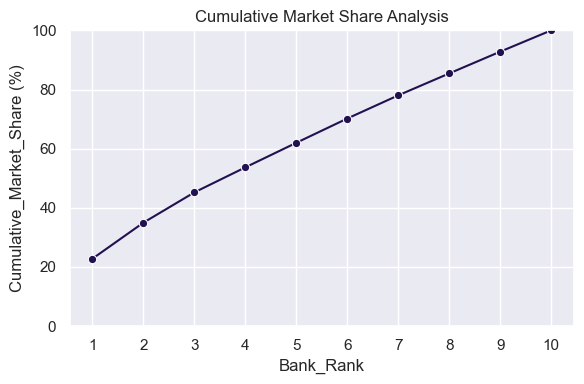

In [56]:
# Plot
plt.figure(figsize=(6,4))

sns.lineplot(x="Bank_Rank",y="Cumulative_Market_Share",data=df_pandas, marker="o")

plt.ylim(0, 100)
plt.xticks(range(1, len(df_pandas)+1)) 

plt.xlabel("Bank_Rank")
plt.ylabel("Cumulative_Market_Share (%)")
plt.title("Cumulative Market Share Analysis")

plt.tight_layout()
plt.show()

##**3.8. Categorising Banks** <font color = red>[5 Marks]</font> <br>

Categorize banks into market capitalization ranges and analyze their distribution using a bar chart.

In [58]:
# Market Cap Range Distribution
# Create market cap ranges
import numpy as np

Market_Cap_Range_Conditions = [
    df_pandas["Market_Capitalisation (USD Billion)"] <= 100,
    (df_pandas["Market_Capitalisation (USD Billion)"] > 100) & (df_pandas["Market_Capitalisation (USD Billion)"] <= 200),
    (df_pandas["Market_Capitalisation (USD Billion)"] > 200) & (df_pandas["Market_Capitalisation (USD Billion)"] <= 400),
    df_pandas["Market_Capitalisation (USD Billion)"] > 400
]

Market_Cap_Range = ['0–100', '100–200', '200–400', '>400']

df_pandas["Market_Cap_Range"] = np.select(Market_Cap_Range_Conditions, Market_Cap_Range, default='unknown')
df_pandas.head(10)

,Bank_Rank,Bank_Name,Market_Capitalisation (USD Billion),Cumulative_Market_Share,Market_Cap_Range
0,1,JPMorgan Chase,432.92,22.787422,>400
1,2,Bank of America,231.52,34.973840,200–400
2,3,Industrial and Commercial Bank of China,194.56,45.214810,100–200
3,4,Agricultural Bank of China,160.68,53.672453,100–200
4,5,HDFC Bank,157.91,61.984293,100–200
5,6,Wells Fargo,155.87,70.188755,100–200
6,7,HSBC Holdings PLC,148.90,78.026339,100–200
7,8,Morgan Stanley,140.83,85.439147,100–200
8,9,China Construction Bank,139.82,92.798791,100–200
9,10,Bank of China,136.81,100.000000,100–200


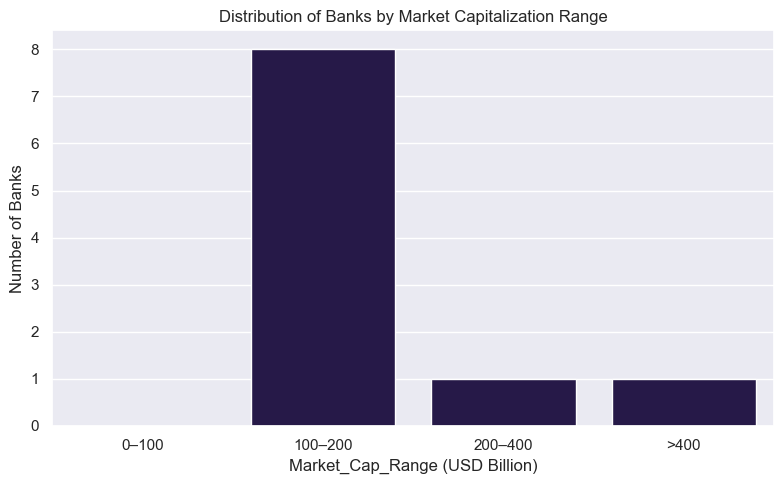

In [59]:
# plot
df_pandas_range_count = df_pandas['Market_Cap_Range'].value_counts().reset_index()
df_pandas_range_count.columns = ['Market_Cap_Range', 'Bank_Count']

plt.figure(figsize=(8,5))
sns.barplot(data=df_pandas_range_count, x='Market_Cap_Range', y='Bank_Count', order= Market_Cap_Range)

plt.title("Distribution of Banks by Market Capitalization Range")
plt.xlabel("Market_Cap_Range (USD Billion)")
plt.ylabel("Number of Banks")

plt.tight_layout()
plt.show()

##**3.9. Visualise Market Share Distribution** <font color = red>[5 Marks]</font> <br>


Calculate and display market share distribution among the top 10 banks using a pie chart.

In [61]:
Top_10_Banks_by_Market_Cap.head(3) # top 10 banks by market cap

,Bank_Rank,Bank_Name,Market_Capitalisation (USD Billion)
0,1,JPMorgan Chase,432.92
1,2,Bank of America,231.52
2,3,Industrial and Commercial Bank of China,194.56


In [62]:
# Top 10 Banks Market Share
# Calculate market share percentage for top 10 banks
market_share_top10_banks=Top_10_Banks_by_Market_Cap.copy()
market_share_top10_banks['Market_Share_%'] = market_share_top10_banks['Market_Capitalisation (USD Billion)']/(market_share_top10_banks['Market_Capitalisation (USD Billion)'].sum())*100

market_share_top10_banks.head()


,Bank_Rank,Bank_Name,Market_Capitalisation (USD Billion),Market_Share_%
0,1,JPMorgan Chase,432.92,22.787422
1,2,Bank of America,231.52,12.186418
2,3,Industrial and Commercial Bank of China,194.56,10.240970
3,4,Agricultural Bank of China,160.68,8.457643
4,5,HDFC Bank,157.91,8.311840


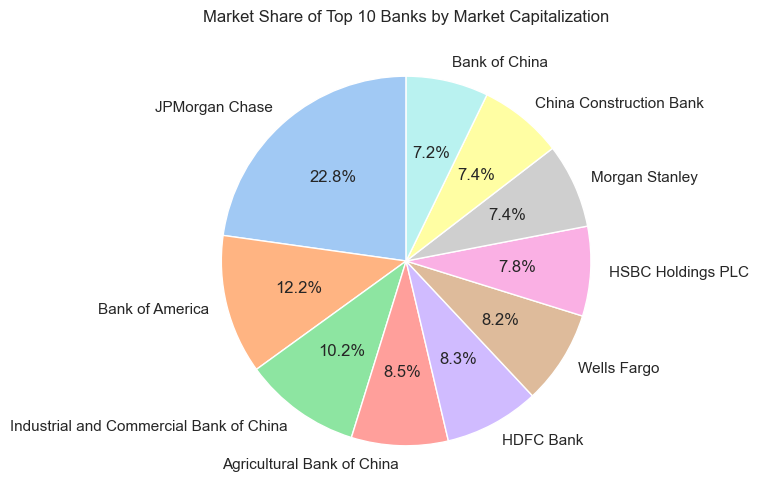

In [63]:
# Plot
plt.figure(figsize=(6,6))
sns.set_palette("pastel")

plt.pie(
    market_share_top10_banks['Market_Share_%'],
    labels=market_share_top10_banks['Bank_Name'],
    autopct='%.1f%%',
    startangle=90
)
plt.title("Market Share of Top 10 Banks by Market Capitalization")
plt.show()


#**4. ETL and Querying** <font color = red>[45 marks]</font> <br>

In [65]:
#Imports & Spark Session Initialization

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, round
import logging
from datetime import datetime
import sqlite3
import pandas as pd

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BankingDataAnalysis") \
    .getOrCreate()

# Logging Configuration
logfile = "code_log.txt"

In [66]:
#Logging Function

def log_progress(msg):
    timeformat = '%Y-%h-%d-%H:%M:%S'
    timestamp = datetime.now().strftime(timeformat)
    with open(logfile, 'a') as f:
        f.write(f"{timestamp} : {msg}\n")

In [67]:
# Import required functions
from pyspark.sql.functions import col, avg, sum, count, desc, asc, round, lag, dense_rank, ntile, when, first, lead
from pyspark.sql.window import Window

# First, let's rename your columns to match our queries (if needed)


# Create window specifications for ranking
window_spec = Window.orderBy(col("Market_Capitalisation (USD Billion)").desc())

# Window for total market cap (no partition, no order)
windowless_spec = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

##**4.1. Market Capitalization Analysis** <font color = red>[3 marks]</font> <br>

Q: Perform Advanced Market Capitalization Analysis with Growth Metrics

In [70]:
df_spark.columns

['Bank_Rank', 'Bank_Name', 'Market_Capitalisation (USD Billion)']

In [71]:
# Query: Advanced Market Cap Analysis with Growth Metrics
market_analysis = df_spark \
    .withColumn("Bank_Rank", dense_rank().over(window_spec)) \
    .withColumn("cumulative_market_cap", sum("Market_Capitalisation (USD Billion)").over(window_spec)) \
    .withColumn("market_share(%)",
                round(col("Market_Capitalisation (USD Billion)") * 100 / sum("Market_Capitalisation (USD Billion)").over(windowless_spec), 2)) \
    .withColumn("gap_from_leader",
                col("Market_Capitalisation (USD Billion)") - first("Market_Capitalisation (USD Billion)").over(window_spec)) \
    .select("Bank_Name", "Market_Capitalisation (USD Billion)", "Bank_Rank",
            "market_share(%)", "cumulative_market_cap", "gap_from_leader") \
    .orderBy("Bank_Rank")

print("Top Banks by Market Cap with Advanced Metrics:")
market_analysis.show()

Top Banks by Market Cap with Advanced Metrics:
+--------------------+-----------------------------------+---------+---------------+---------------------+-------------------+
|           Bank_Name|Market_Capitalisation (USD Billion)|Bank_Rank|market_share(%)|cumulative_market_cap|    gap_from_leader|
+--------------------+-----------------------------------+---------+---------------+---------------------+-------------------+
|      JPMorgan Chase|                             432.92|        1|          22.79|               432.92|                0.0|
|     Bank of America|                             231.52|        2|          12.19|               664.44|             -201.4|
|Industrial and Co...|                             194.56|        3|          10.24|                859.0|            -238.36|
|Agricultural Bank...|                             160.68|        4|           8.46|   1019.6800000000001|            -272.24|
|           HDFC Bank|                             157.91|      

##4.2.**Market Concentration Analysis** <font color = red>[6 marks]</font> <br>

Q: Analyze Market Concentration and Categorize Banks Based on Market Share Tiers

In [73]:
df_spark.columns

['Bank_Rank', 'Bank_Name', 'Market_Capitalisation (USD Billion)']

In [74]:
# Market Concentration Analysis
market_cap_sum = df_spark.agg(sum("Market_Capitalisation (USD Billion)")).collect()[0][0]

df_spark = df_spark.withColumn(
    "Market_Share(%)",
    round((col("Market_Capitalisation (USD Billion)") / market_cap_sum) * 100, 2)
)
df_spark.show(3)

+---------+--------------------+-----------------------------------+---------------+
|Bank_Rank|           Bank_Name|Market_Capitalisation (USD Billion)|Market_Share(%)|
+---------+--------------------+-----------------------------------+---------------+
|        1|      JPMorgan Chase|                             432.92|          22.79|
|        2|     Bank of America|                             231.52|          12.19|
|        3|Industrial and Co...|                             194.56|          10.24|
+---------+--------------------+-----------------------------------+---------------+
only showing top 3 rows


In [75]:
df_spark = df_spark.withColumn(
    "Market_Share_Tier",
    when(col("Market_Share(%)") > 5, "Tier-1: >5%")
    .when((col("Market_Share(%)") > 2) & (col("Market_Share(%)") <= 5), "Tier-2: 2–5%")
    .when((col("Market_Share(%)") > 1) & (col("Market_Share(%)") <= 2), "Tier-3: 1–2%")
    .otherwise("Tier-4: <1%")
)

In [76]:
tier_count_spark = df_spark.groupBy("Market_Share_Tier").count().orderBy("Market_Share_Tier")
tier_count_spark.show()

+-----------------+-----+
|Market_Share_Tier|count|
+-----------------+-----+
|      Tier-1: >5%|   10|
+-----------------+-----+



##**4.3. Market Capitalization Distribution** <font color = red>[6 marks]</font> <br>

Q: Examine Statistical Distribution of Market Capitalization Using Quartile Analysis

In [78]:
# Import required functions
from pyspark.sql.functions import (col, avg, sum, count, desc, asc, round, lag,
                                 dense_rank, ntile, when, first, lead, min, max, lit)
from pyspark.sql.window import Window

# Query 3: Statistical Distribution Analysis

quartiles = df_spark.select(
    percentile_approx(col("Market_Capitalisation (USD Billion)"), 0.25).alias("Q1"),
    percentile_approx(col("Market_Capitalisation (USD Billion)"), 0.50).alias("Median"),
    percentile_approx(col("Market_Capitalisation (USD Billion)"), 0.75).alias("Q3")
).collect()[0]

Q1 = quartiles["Q1"]
Median = quartiles["Median"]
Q3 = quartiles["Q3"]

print(f"Q1: {Q1}, Median: {Median}, Q3: {Q3}")

# Add Quartile Category Column
df_quartile = df_spark.withColumn(
    "Market_Cap_Quartile",
    expr(f"""
        CASE 
            WHEN `Market_Capitalisation (USD Billion)` <= {Q1} THEN 'Low (Q1)'
            WHEN `Market_Capitalisation (USD Billion)` > {Q1} AND `Market_Capitalisation (USD Billion)` <= {Median} THEN 'Lower-Mid (Q2)'
            WHEN `Market_Capitalisation (USD Billion)` > {Median} AND `Market_Capitalisation (USD Billion)` <= {Q3} THEN 'Upper-Mid (Q3)'
            ELSE 'High (Q4)'
        END
    """)
)

# Show result
df_quartile.select("Bank_Name", "Market_Capitalisation (USD Billion)", "Market_Cap_Quartile").show(10)


Q1: 140.83, Median: 155.87, Q3: 194.56
+--------------------+-----------------------------------+-------------------+
|           Bank_Name|Market_Capitalisation (USD Billion)|Market_Cap_Quartile|
+--------------------+-----------------------------------+-------------------+
|      JPMorgan Chase|                             432.92|          High (Q4)|
|     Bank of America|                             231.52|          High (Q4)|
|Industrial and Co...|                             194.56|     Upper-Mid (Q3)|
|Agricultural Bank...|                             160.68|     Upper-Mid (Q3)|
|           HDFC Bank|                             157.91|     Upper-Mid (Q3)|
|         Wells Fargo|                             155.87|     Lower-Mid (Q2)|
|   HSBC Holdings PLC|                              148.9|     Lower-Mid (Q2)|
|      Morgan Stanley|                             140.83|           Low (Q1)|
|China Constructio...|                             139.82|           Low (Q1)|
|       Bank 

##**4.4. Comparative Size Analysis** <font color = red>[6 marks]</font> <br>

Q: Conduct Comparative Size Analysis to Classify Banks by Relative Market Size

In [80]:
# Comparative Size Analysis
df_relative_size = df_spark.withColumn(
    "Market_Size_Category",
    when(col("Market_Capitalisation (USD Billion)") > 300, "Mega Cap")
    .when((col("Market_Capitalisation (USD Billion)") > 100) & (col("Market_Capitalisation (USD Billion)") <= 300), "Large Cap")
    .when((col("Market_Capitalisation (USD Billion)") > 30) & (col("Market_Capitalisation (USD Billion)") <= 100), "Mid Cap")
    .otherwise("Small Cap")
)

# Display
df_relative_size.select("Bank_Name", "Market_Capitalisation (USD Billion)", "Market_Size_Category").show(10)


+--------------------+-----------------------------------+--------------------+
|           Bank_Name|Market_Capitalisation (USD Billion)|Market_Size_Category|
+--------------------+-----------------------------------+--------------------+
|      JPMorgan Chase|                             432.92|            Mega Cap|
|     Bank of America|                             231.52|           Large Cap|
|Industrial and Co...|                             194.56|           Large Cap|
|Agricultural Bank...|                             160.68|           Large Cap|
|           HDFC Bank|                             157.91|           Large Cap|
|         Wells Fargo|                             155.87|           Large Cap|
|   HSBC Holdings PLC|                              148.9|           Large Cap|
|      Morgan Stanley|                             140.83|           Large Cap|
|China Constructio...|                             139.82|           Large Cap|
|       Bank of China|                  

In [81]:
# Count banks per relative category
df_relative_size.groupBy("Market_Size_Category").count().show()

+--------------------+-----+
|Market_Size_Category|count|
+--------------------+-----+
|            Mega Cap|    1|
|           Large Cap|    9|
+--------------------+-----+



##**4.5. Market Growth Analysis** <font color = red>[6 marks]</font> <br>

Q: Evaluate Market Growth and Identify Gaps Between Consecutive Banks

In [83]:
# Growth and Gap Analysis

gap_analysis = df_spark \
    .withColumn("Bank_Rank", dense_rank().over(window_spec)) \
    .withColumn("next_cap", lead("Market_Capitalisation (USD Billion)").over(window_spec)) \
    .withColumn("gap_to_next", round(col("Market_Capitalisation (USD Billion)") - col("next_cap"), 2)) \
    .withColumn("gap_percentage",
                round((col("Market_Capitalisation (USD Billion)") - col("next_cap")) * 100 / col("Market_Capitalisation (USD Billion)"), 2)) \
    .select("Bank_Name", "Market_Capitalisation (USD Billion)", "Bank_Rank", "gap_to_next", "gap_percentage") \
    .filter(col("gap_to_next").isNotNull()) \
    .orderBy("Bank_Rank")

print("Market Cap Gaps Between Consecutive Banks:")
gap_analysis.show()

Market Cap Gaps Between Consecutive Banks:
+--------------------+-----------------------------------+---------+-----------+--------------+
|           Bank_Name|Market_Capitalisation (USD Billion)|Bank_Rank|gap_to_next|gap_percentage|
+--------------------+-----------------------------------+---------+-----------+--------------+
|      JPMorgan Chase|                             432.92|        1|      201.4|         46.52|
|     Bank of America|                             231.52|        2|      36.96|         15.96|
|Industrial and Co...|                             194.56|        3|      33.88|         17.41|
|Agricultural Bank...|                             160.68|        4|       2.77|          1.72|
|           HDFC Bank|                             157.91|        5|       2.04|          1.29|
|         Wells Fargo|                             155.87|        6|       6.97|          4.47|
|   HSBC Holdings PLC|                              148.9|        7|       8.07|          5.4

##**4.6. Market Dominance Analysis** <font color = red>[6 marks]</font> <br>

Q: Assess Market Dominance by Measuring Cumulative Share and Dominance Score

In [85]:
# Market Dominance Analysis
# Rank and compute cumulative market share

# Ranking
df_spark= df_spark.withColumn("Rank", rank().over(window_spec)) # window_spec is defined in cell 132

# Cumulative Market Share
df_spark = df_spark.withColumn(
    "Cumulative_Market_Share(%)",
    sum(col("Market_Share(%)")).over(window_spec)
)

# Add Dominance_Score
df_spark = df_spark.withColumn(
    "Dominance_Score",
    col("Market_Share(%)") / col("Bank_Rank") 
)

# Dominance_Category

df_spark = df_spark.withColumn(
    "Dominance_Category",
    when(col("Dominance_Score") >= 5, "Dominant")  
    .when(col("Dominance_Score") >= 2, "Major")
    .when(col("Dominance_Score") >= 1, "Competitive")
    .otherwise("Niche")
)

# Display
df_spark.select(
    "Bank_Name", "Market_Share(%)", "Rank",
    "Cumulative_Market_Share(%)", "Dominance_Score", "Dominance_Category"
).orderBy("Rank").show(10)

+--------------------+---------------+----+--------------------------+------------------+------------------+
|           Bank_Name|Market_Share(%)|Rank|Cumulative_Market_Share(%)|   Dominance_Score|Dominance_Category|
+--------------------+---------------+----+--------------------------+------------------+------------------+
|      JPMorgan Chase|          22.79|   1|                     22.79|             22.79|          Dominant|
|     Bank of America|          12.19|   2|                     34.98|             6.095|          Dominant|
|Industrial and Co...|          10.24|   3|                     45.22|3.4133333333333336|             Major|
|Agricultural Bank...|           8.46|   4|                     53.68|             2.115|             Major|
|           HDFC Bank|           8.31|   5|                     61.99|1.6620000000000001|       Competitive|
|         Wells Fargo|            8.2|   6|                     70.19|1.3666666666666665|       Competitive|
|   HSBC Holdings P

##**4.7. Segment-Wise Bank Analysis** <font color = red>[6 marks]</font> <br>

Q: Analyze Segment-Wise Bank Performance Based on Market Capitalization Ranges

In [87]:
# Segment Performance Analysis
# Define Market-Cap Segments in Spark
df_relative_size.show(5) # this was created in previous analysis


+---------+--------------------+-----------------------------------+---------------+-----------------+--------------------+
|Bank_Rank|           Bank_Name|Market_Capitalisation (USD Billion)|Market_Share(%)|Market_Share_Tier|Market_Size_Category|
+---------+--------------------+-----------------------------------+---------------+-----------------+--------------------+
|        1|      JPMorgan Chase|                             432.92|          22.79|      Tier-1: >5%|            Mega Cap|
|        2|     Bank of America|                             231.52|          12.19|      Tier-1: >5%|           Large Cap|
|        3|Industrial and Co...|                             194.56|          10.24|      Tier-1: >5%|           Large Cap|
|        4|Agricultural Bank...|                             160.68|           8.46|      Tier-1: >5%|           Large Cap|
|        5|           HDFC Bank|                             157.91|           8.31|      Tier-1: >5%|           Large Cap|
+-------

In [88]:
# Perform Segment-Wise analysis
df_segment_analysis = df_relative_size.groupBy("Market_Size_Category").agg(
    count("*").alias("Number_of_Banks"),
    round(avg("Market_Capitalisation (USD Billion)"), 2).alias("Avg_Market_Cap"),
    round(sum("Market_Capitalisation (USD Billion)"), 2).alias("Total_Market_Cap"),
    round(sum("Market_Share(%)"), 2).alias("Total_Market_Share(%)")
).orderBy("Total_Market_Cap", ascending=False)

df_segment_analysis.show()

+--------------------+---------------+--------------+----------------+---------------------+
|Market_Size_Category|Number_of_Banks|Avg_Market_Cap|Total_Market_Cap|Total_Market_Share(%)|
+--------------------+---------------+--------------+----------------+---------------------+
|           Large Cap|              9|        162.99|          1466.9|                77.21|
|            Mega Cap|              1|        432.92|          432.92|                22.79|
+--------------------+---------------+--------------+----------------+---------------------+



##**4.8. Performance Dashboard** <font color = red>[6 marks]</font> <br>

Q: Generate a Comprehensive Performance Dashboard for Bank Rankings and Metrics

In [96]:
# Comprehensive Performance Dashboard

Df_Dashboard = (
    df_spark
    .withColumn("Rank", rank().over(window_spec))
    .withColumn(
        "Market_Size_Category",
    when(col("Market_Capitalisation (USD Billion)") > 300, "Mega Cap")
    .when((col("Market_Capitalisation (USD Billion)") > 100) & (col("Market_Capitalisation (USD Billion)") <= 300), "Large Cap")
    .when((col("Market_Capitalisation (USD Billion)") > 30) & (col("Market_Capitalisation (USD Billion)") <= 100), "Mid Cap")
    .otherwise("Small Cap")
)
    .withColumn( "Market_Cap_Quartile",
    expr(f"""
        CASE 
            WHEN `Market_Capitalisation (USD Billion)` <= {Q1} THEN 'Low (Q1)'
            WHEN `Market_Capitalisation (USD Billion)` > {Q1} AND `Market_Capitalisation (USD Billion)` <= {Median} THEN 'Lower-Mid (Q2)'
            WHEN `Market_Capitalisation (USD Billion)` > {Median} AND `Market_Capitalisation (USD Billion)` <= {Q3} THEN 'Upper-Mid (Q3)'
            ELSE 'High (Q4)'
        END
    """)
)
    .withColumn("Market_Share_Tier",
    when(col("Market_Share(%)") > 5, "Tier-1: >5%")
    .when((col("Market_Share(%)") > 2) & (col("Market_Share(%)") <= 5), "Tier-2: 2–5%")
    .when((col("Market_Share(%)") > 1) & (col("Market_Share(%)") <= 2), "Tier-3: 1–2%")
    .otherwise("Tier-4: <1%")
)
    .withColumn("Dominance_Score",col("Market_Share(%)") / col("Rank"))
    .withColumn("Dominance_Category",
    when(col("Dominance_Score") >= 5, "Dominant")  
    .when(col("Dominance_Score") >= 2, "Major")
    .when(col("Dominance_Score") >= 1, "Competitive")
    .otherwise("Niche")
)

    .withColumn(
        "market_cap_segment",
        when(col("Market_Capitalisation (USD Billion)") > 300, "Large (>300B)")
        .when((col("Market_Capitalisation (USD Billion)") > 150) & (col("Market_Capitalisation (USD Billion)") <= 300), "Medium (150-300B)")
        .otherwise("Small (<=150B)")
    )
    .select(
        "Rank",
        "Bank_Name",
        "Market_Capitalisation (USD Billion)",
        "Market_Size_Category",
        "Market_Cap_Quartile",
        "Market_Share(%)",
        "Market_Share_Tier",
        "Dominance_Score",
        "Dominance_Category"
    )
    .orderBy("Rank")
)

print("Comprehensive Bank Performance Dashboard:")
Df_Dashboard.show(truncate=False)


Comprehensive Bank Performance Dashboard:
+----+---------------------------------------+-----------------------------------+--------------------+-------------------+---------------+-----------------+------------------+------------------+
|Rank|Bank_Name                              |Market_Capitalisation (USD Billion)|Market_Size_Category|Market_Cap_Quartile|Market_Share(%)|Market_Share_Tier|Dominance_Score   |Dominance_Category|
+----+---------------------------------------+-----------------------------------+--------------------+-------------------+---------------+-----------------+------------------+------------------+
|1   |JPMorgan Chase                         |432.92                             |Mega Cap            |High (Q4)          |22.79          |Tier-1: >5%      |22.79             |Dominant          |
|2   |Bank of America                        |231.52                             |Large Cap           |High (Q4)          |12.19          |Tier-1: >5%      |6.095            

In [ ]:
# Plot for dashboard

# Install Plotly
!{sys.executable} -m pip install plotly

# Convert Dashbord data pandas for visualisation
Df_Dashboard_pd= Df_Dashboard.toPandas()

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ---- Charts ----

# 1 Market Cap Bar
fig1 = px.bar(
    Df_Dashboard_pd,
    x="Bank_Name",
    y="Market_Capitalisation (USD Billion)",
    color="Market_Size_Category",
    title="Market Capitalisation by Bank"
)

# 2 Market Share Pie
fig2 = px.pie(
    Df_Dashboard_pd,
    values="Market_Share(%)",
    names="Bank_Name",
    title="Market Share Distribution"
)

# 3 Quartile Box Plot
fig3 = px.box(
    Df_Dashboard_pd,
    y="Market_Capitalisation (USD Billion)",
    points="all",
    title="Market Capitalisation Quartile Distribution"
)

# 4 Size Category Count
fig4 = px.bar(
    Df_Dashboard_pd["Market_Size_Category"].value_counts().reset_index(),
    x="index",
    y="Market_Size_Category",
    title="Bank Count by Market Size Category",
    labels={"index": "Category", "Market_Size_Category": "Count"}
)

# 5 Dominance Score Bar
fig5 = px.bar(
    Df_Dashboard_pd.sort_values("Dominance_Score", ascending=False),
    x="Bank_Name",
    y="Dominance_Score",
    color="Dominance_Category",
    title="Dominance Score by Bank"
)

# 6 Cumulative Market Share by Rank
Df_Dashboard_pd["Cumulative"] = Df_Dashboard_pd["Market_Share(%)"].cumsum()
fig6 = px.line(
    Df_Dashboard_pd,
    x="Bank_Rank",
    y="Cumulative",
    markers=True,
    title="Cumulative Market Share vs Rank"
)

# ---- Dashboard Layout ----
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        "Market Cap by Bank",
        "Market Share Distribution",
        "Quartile Distribution",
        "Bank Category Count",
        "Dominance Score",
        "Cumulative Market Share"
    ],
    specs=[[{"type": "bar"}, {"type": "pie"}],
           [{"type": "box"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "scatter"}]]
)

for trace in fig1.data: fig.add_trace(trace, row=1, col=1)
for trace in fig2.data: fig.add_trace(trace, row=1, col=2)
for trace in fig3.data: fig.add_trace(trace, row=2, col=1)
for trace in fig4.data: fig.add_trace(trace, row=2, col=2)
for trace in fig5.data: fig.add_trace(trace, row=3, col=1)
for trace in fig6.data: fig.add_trace(trace, row=3, col=2)

fig.update_layout(height=1500, width=1200, title_text="Comprehensive Global Bank Market Dashboard")
fig.show()


#5. Visualization Integration

In [ ]:
# Visualization Setup Section

# 1. Prepare data for visualization platforms
# 2. Generate Tableau connection instructions

# 3. Generate Power BI connection instructions

# 4. Execute visualization setup
# 5. Sample Dashboard Layout (Documentation)
